# FM 频带预条件：从 Toy 因果门到真实 RAE 审计

## TL;DR

这个 notebook 不直接训练新的 RAE，而是回答是否值得训练。证据分两层：

1. **因果 toy**：把完整权重严格拆成 `time-only × direction-only`，排除时间重加权和
   全局 loss scale 混杂，并用 5 个 paired seeds、ODE 终点与 decoder-gain permutation 检查。
2. **真实 RAE 无训练审计**：读取官方 DINOv2 latent、DiTDH-S checkpoint 和 frozen decoder，
   测量 DCT/PCA band residual、held-out teacher predictability、final-head 梯度噪声和 decoder 敏感度。

**执行结果**：`direction-only gamma=.5` 在 toy ODE 上平均改善 11.7%（4/5 seeds），而
`time-only` 恶化 12.9%（0/5）；MLP raw MSE 稳定改善 15.2%，但 mini-DiT 两个 batch
合并后的 raw MSE 并未改善。真实 RAE 的 DCT band residual 跨度约 23.5 倍，远强于随机基；
teacher `rho` 从低频约 0.80 降到高频约 0.27，decoder sensitivity 与 residual 的
Spearman 为 -0.95。`gamma=.5` 将 final-head 梯度方差斜率从 1.64 降到 0.67，
但 B=64 的整体 projected GSNR 只保留 baseline 的 0.59 倍。

**结论**：通过一次 tiny RAE microtraining 的门槛，但未通过大训练门槛，也不能称为通用加速。

最后一节根据执行结果自动给出研究门槛。这里的 `B=1024` GSNR 是 IID 外推；
`B=4/16/64` 才是当前样本上的经验估计。

## Context & Methods

### Causal factorization

对 band residual scale $R_b(t)$ 定义原始权重

$$q_b(t)=(R_b(t)+\delta)^{-\gamma}.$$

将其严格分解为

$$q_b^{\rm dir}(t)=\frac{q_b(t)}{\langle q(t)\rangle_b},\qquad
q^{\rm time}(t)=\frac{\langle q(t)\rangle_b}{\mathbb E_{t,b}[q_b(t)]},$$

因而 $q^{\rm full}=q^{\rm dir}q^{\rm time}$。`direction-only` 在每个 $t$ 内平均权重恒为 1；
`time-only` 在同一 $t$ 的所有方向上相同；所有完整/时间权重的全局均值为 1。

### Real RAE audit

使用官方路径

$$x_t=(1-t)z+t\epsilon,\qquad v_t=\epsilon-z,$$

以及 shifted logit-normal $t$。每个 band 的最佳标量 linear skip 在 train latent 上拟合，
residual 和官方 teacher error 在 ImageNet validation latent 上评估。对 final linear head，捕获其输入
$H$，并直接计算 $E^TH$ 的随机投影，因此不需要反传 ViT，也没有微调或数据泄露。

### Key Assumptions

- RAE latent cache 恢复了 cache 构建时除掉的单一 RMS scale，输入与官方 stage-2 约定一致。
- channel PCA 只用 cache train split；teacher error、梯度与 decoder sensitivity 使用 validation split。
- teacher error 给出的 $\rho$ 是 predictor 能力相关的下界，不是真实 Bayes predictability。
- final-head gradient sketch 保留 treatment 间的相对比较，但不等同于全网络梯度协方差。
- DCT 频带是诊断基，不预设它一定是最优训练基；随机正交基作为结构性对照。

## Data

### 1. Load executed artifacts

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

TOY_DIR = Path.home() / "data/eqvae/experiments/fm_weighting_gate_full"
RAE_DIR = Path.home() / "data/eqvae/experiments/rae_spectral_gradient_audit_full"

required = {
    TOY_DIR: ["history.csv", "summary.csv", "generation.csv", "decoder_permutations.csv", "weight_diagnostics.csv"],
    RAE_DIR: ["residual_table.csv", "basis_control.csv", "gradient_summary.csv", "gradient_bands.csv", "cross_band_correlation.csv", "decoder_sensitivity.csv", "decoder_sensitivity_sweep.csv"],
}
missing = [str(folder / name) for folder, names in required.items() for name in names if not (folder / name).exists()]
if missing:
    raise FileNotFoundError("缺少正式实验 artifact:\n" + "\n".join(missing))

toy_history = pd.read_csv(TOY_DIR / "history.csv")
toy_summary = pd.read_csv(TOY_DIR / "summary.csv")
toy_generation = pd.read_csv(TOY_DIR / "generation.csv")
toy_permutations = pd.read_csv(TOY_DIR / "decoder_permutations.csv")
weight_diagnostics = pd.read_csv(TOY_DIR / "weight_diagnostics.csv")
rae_residual = pd.read_csv(RAE_DIR / "residual_table.csv")
basis_control = pd.read_csv(RAE_DIR / "basis_control.csv")
gradient_summary = pd.read_csv(RAE_DIR / "gradient_summary.csv")
gradient_bands = pd.read_csv(RAE_DIR / "gradient_bands.csv")
cross_band = pd.read_csv(RAE_DIR / "cross_band_correlation.csv")
decoder_sensitivity = pd.read_csv(RAE_DIR / "decoder_sensitivity.csv")
decoder_sweep = pd.read_csv(RAE_DIR / "decoder_sensitivity_sweep.csv")
toy_metadata = json.loads((TOY_DIR / "metadata.json").read_text())
rae_metadata = json.loads((RAE_DIR / "metadata.json").read_text())

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.sans-serif": ["Noto Sans CJK JP", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = {
    "baseline:gamma=0": "#111827",
    "time:gamma=0.5": "#0F766E",
    "direction:gamma=0.5": "#2563EB",
    "full:gamma=0.5": "#CA8A04",
    "direction:gamma=1": "#7C3AED",
    "full:gamma=1": "#DC2626",
}
ORDER = list(COLORS)
print(f"toy runs: {len(toy_summary)} | seeds: {toy_metadata['seeds']}")
print(f"RAE train/validation: {rae_metadata['train_count']}/{rae_metadata['validation_count']}")
print(f"RAE checkpoint: {rae_metadata['checkpoint']}")

toy runs: 90 | seeds: [0, 1, 2, 3, 4]
RAE train/validation: 256/64
RAE checkpoint: /home/zhoushunyu/data/eqvae/models/RAE/DiTs/Dinov2/wReg_base/ImageNet256/DiTDH-S_ep14/stage2_model.pt


### 2. Verify split and weighting invariants

In [2]:
invariant_view = weight_diagnostics[[
    "treatment", "mean_weight", "per_time_mean_cv", "mean_within_time_cv", "max_weight"
]].copy()
display(invariant_view.round(5))

assert np.isclose(weight_diagnostics.query("mode == 'direction'")["per_time_mean_cv"], 0, atol=1e-10).all()
assert np.isclose(weight_diagnostics.query("mode == 'time'")["mean_within_time_cv"], 0, atol=1e-10).all()
assert set(toy_summary.seed) == set(toy_metadata["seeds"])
assert rae_metadata["config"]["train_count"] <= 2048
assert rae_metadata["config"]["validation_count"] <= 512
print("通过：方向轴、时间轴和 train/validation 数据源均按设计分离。")

,treatment,mean_weight,per_time_mean_cv,mean_within_time_cv,max_weight
0,baseline:gamma=0,1.0,0.00000,0.00000,1.00000
1,time:gamma=0.5,1.0,0.21332,0.00000,1.49462
2,direction:gamma=0.5,1.0,0.00000,0.48284,2.59967
3,full:gamma=0.5,1.0,0.21332,0.48284,3.88553
4,direction:gamma=1,1.0,0.00000,0.89453,4.12111
5,full:gamma=1,1.0,0.61189,0.89453,10.24192


通过：方向轴、时间轴和 train/validation 数据源均按设计分离。


## Results

### 3. Toy causal gate

In [3]:
def setup_label(frame):
    return frame["architecture"] + " / B=" + frame["batch_size"].astype(str)

toy_summary["setup"] = setup_label(toy_summary)
aggregate = toy_summary.groupby(["setup", "treatment"], as_index=False).agg(
    final_excess=("final_excess_mse", "mean"),
    excess_auc=("excess_auc", "mean"),
    decoder_mse=("final_decoder_weighted_mse", "mean"),
    clip_rate=("clip_rate", "mean"),
)
baseline = aggregate.query("treatment == 'baseline:gamma=0'")[["setup", "final_excess", "excess_auc", "decoder_mse"]]
baseline = baseline.rename(columns={name: f"baseline_{name}" for name in ["final_excess", "excess_auc", "decoder_mse"]})
aggregate = aggregate.merge(baseline, on="setup")
seed_baseline = toy_summary.query("treatment == 'baseline:gamma=0'")[[
    "setup", "seed", "final_excess_mse", "excess_auc", "final_decoder_weighted_mse"
]].rename(columns={
    "final_excess_mse": "seed_baseline_final_excess",
    "excess_auc": "seed_baseline_excess_auc",
    "final_decoder_weighted_mse": "seed_baseline_decoder_mse",
})
paired_rows = toy_summary.merge(seed_baseline, on=["setup", "seed"])
paired_rows["gain_final_excess"] = (paired_rows["seed_baseline_final_excess"] - paired_rows["final_excess_mse"]) / paired_rows["seed_baseline_final_excess"]
paired_rows["gain_excess_auc"] = (paired_rows["seed_baseline_excess_auc"] - paired_rows["excess_auc"]) / paired_rows["seed_baseline_excess_auc"]
paired_rows["gain_decoder_mse"] = (paired_rows["seed_baseline_decoder_mse"] - paired_rows["final_decoder_weighted_mse"]) / paired_rows["seed_baseline_decoder_mse"]
paired_gain = paired_rows.groupby(["setup", "treatment"], as_index=False)[[
    "gain_final_excess", "gain_excess_auc", "gain_decoder_mse"
]].mean()
aggregate = aggregate.merge(paired_gain, on=["setup", "treatment"])

generation_aggregate = toy_generation.groupby("treatment", as_index=False).agg(
    mean_w1=("mean_coordinate_w1", "mean"),
    mean_w1_std=("mean_coordinate_w1", "std"),
    covariance_error=("covariance_rel_fro", "mean"),
)
generation_baseline = float(generation_aggregate.query("treatment == 'baseline:gamma=0'")["mean_w1"].iloc[0])
generation_aggregate["w1_gain"] = (generation_baseline - generation_aggregate["mean_w1"]) / generation_baseline

display(aggregate[["setup", "treatment", "gain_final_excess", "gain_excess_auc", "gain_decoder_mse", "clip_rate"]].round(4))
display(generation_aggregate.round(5))

,setup,treatment,gain_final_excess,gain_excess_auc,gain_decoder_mse,clip_rate
0,mini_dit / B=256,baseline:gamma=0,0.0000,0.0000,0.0000,0.4744
1,mini_dit / B=256,direction:gamma=0.5,-0.0661,0.0152,0.3121,0.2128
2,mini_dit / B=256,direction:gamma=1,-1.1761,-0.3449,0.1513,0.0904
3,mini_dit / B=256,full:gamma=0.5,0.0510,0.0206,0.3888,0.1368
4,mini_dit / B=256,full:gamma=1,-0.5434,-0.4254,0.3467,0.0108
5,mini_dit / B=256,time:gamma=0.5,0.0174,-0.0236,0.0030,0.3840
6,mini_dit / B=64,baseline:gamma=0,0.0000,0.0000,0.0000,0.6896
7,mini_dit / B=64,direction:gamma=0.5,0.0108,-0.0172,0.3621,0.3600
8,mini_dit / B=64,direction:gamma=1,-1.0851,-0.5577,-0.0843,0.2088
9,mini_dit / B=64,full:gamma=0.5,-0.0003,-0.0530,0.3764,0.2808


,treatment,mean_w1,mean_w1_std,covariance_error,w1_gain
0,baseline:gamma=0,0.05689,0.01410,0.03747,0.00000
1,direction:gamma=0.5,0.05021,0.01278,0.03878,0.11737
2,direction:gamma=1,0.07064,0.03081,0.04842,-0.24171
3,full:gamma=0.5,0.05285,0.01466,0.03674,0.07101
4,full:gamma=1,0.08230,0.02543,0.04198,-0.44669
5,time:gamma=0.5,0.06424,0.01066,0.03636,-0.12927


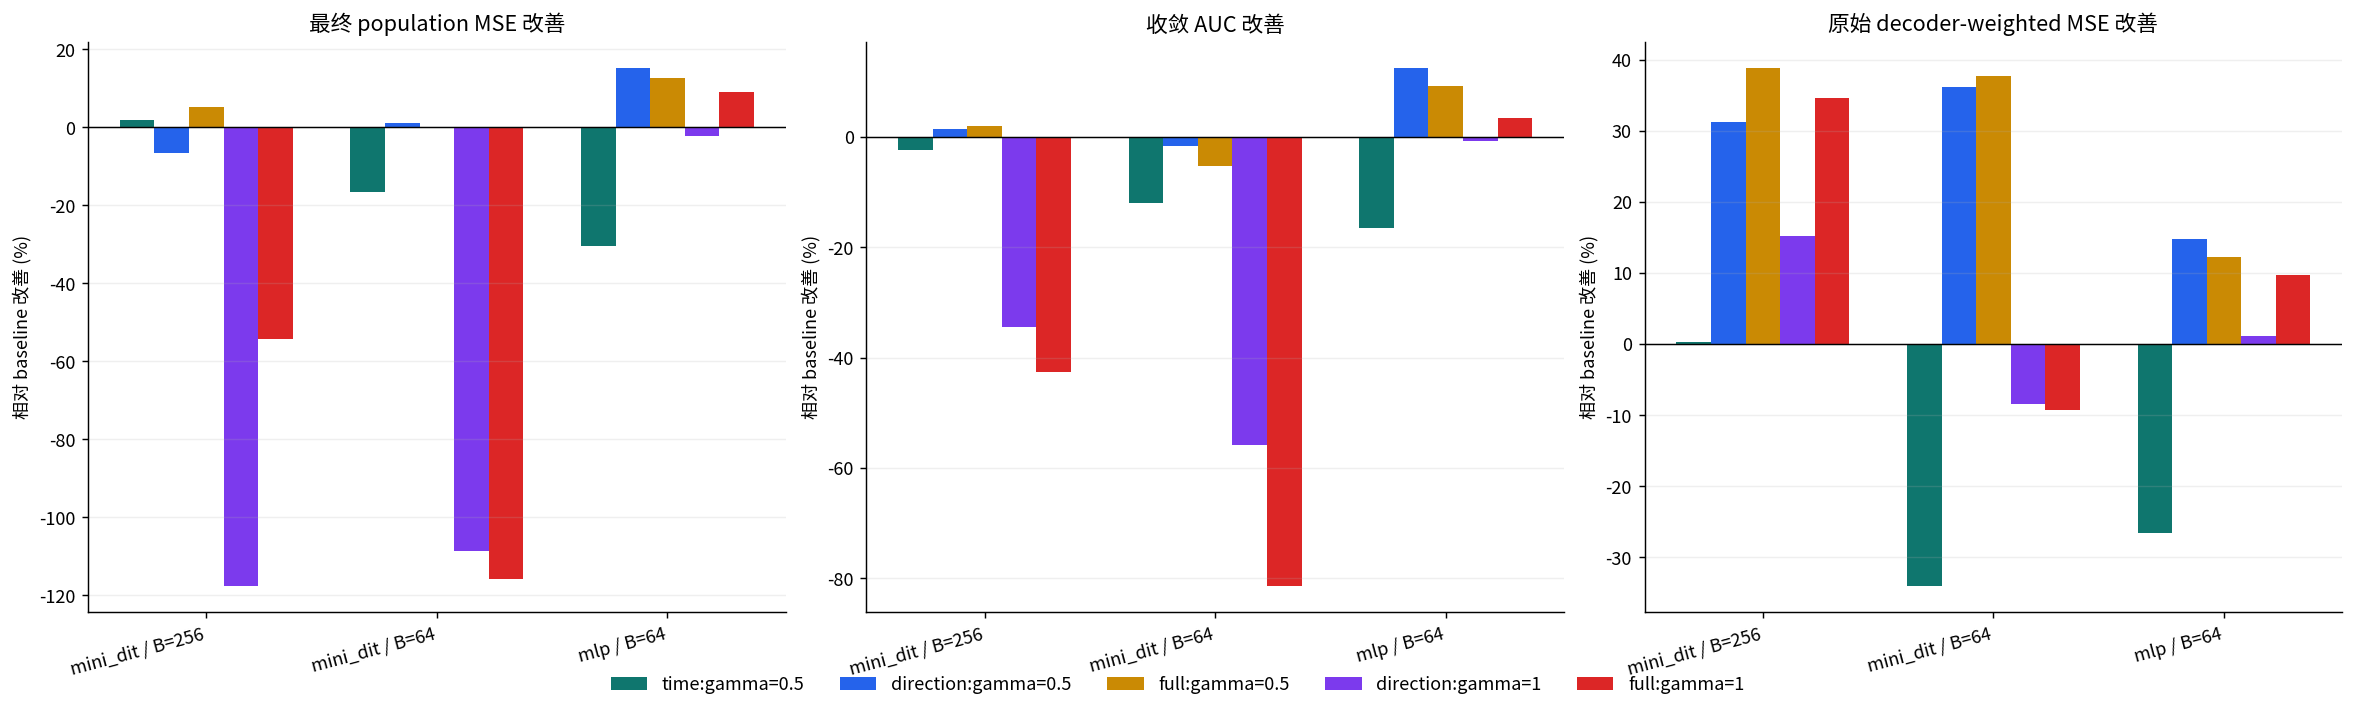

In [4]:
def plot_toy_gate():
    figure, axes = plt.subplots(1, 3, figsize=(18, 5.2), constrained_layout=True)
    metrics = [
        ("gain_final_excess", "最终 population MSE 改善"),
        ("gain_excess_auc", "收敛 AUC 改善"),
        ("gain_decoder_mse", "原始 decoder-weighted MSE 改善"),
    ]
    setups = list(aggregate["setup"].drop_duplicates())
    treatments = [name for name in ORDER if name != "baseline:gamma=0"]
    width = 0.15
    x = np.arange(len(setups))
    for axis, (metric, title) in zip(axes, metrics):
        for offset, treatment in enumerate(treatments):
            selected = aggregate.query("treatment == @treatment").set_index("setup").reindex(setups)
            axis.bar(x + (offset - 2) * width, 100 * selected[metric], width, color=COLORS[treatment], label=treatment)
        axis.axhline(0, color="black", linewidth=0.8)
        axis.set_xticks(x, setups, rotation=15, ha="right")
        axis.set_ylabel("相对 baseline 改善 (%)")
        axis.set_title(title)
        axis.grid(axis="y", alpha=0.2)
    handles, labels = axes[-1].get_legend_handles_labels()
    figure.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.04), ncol=5, frameon=False)
    return figure

plot_toy_gate();

### 4. ODE endpoint and decoder permutation control

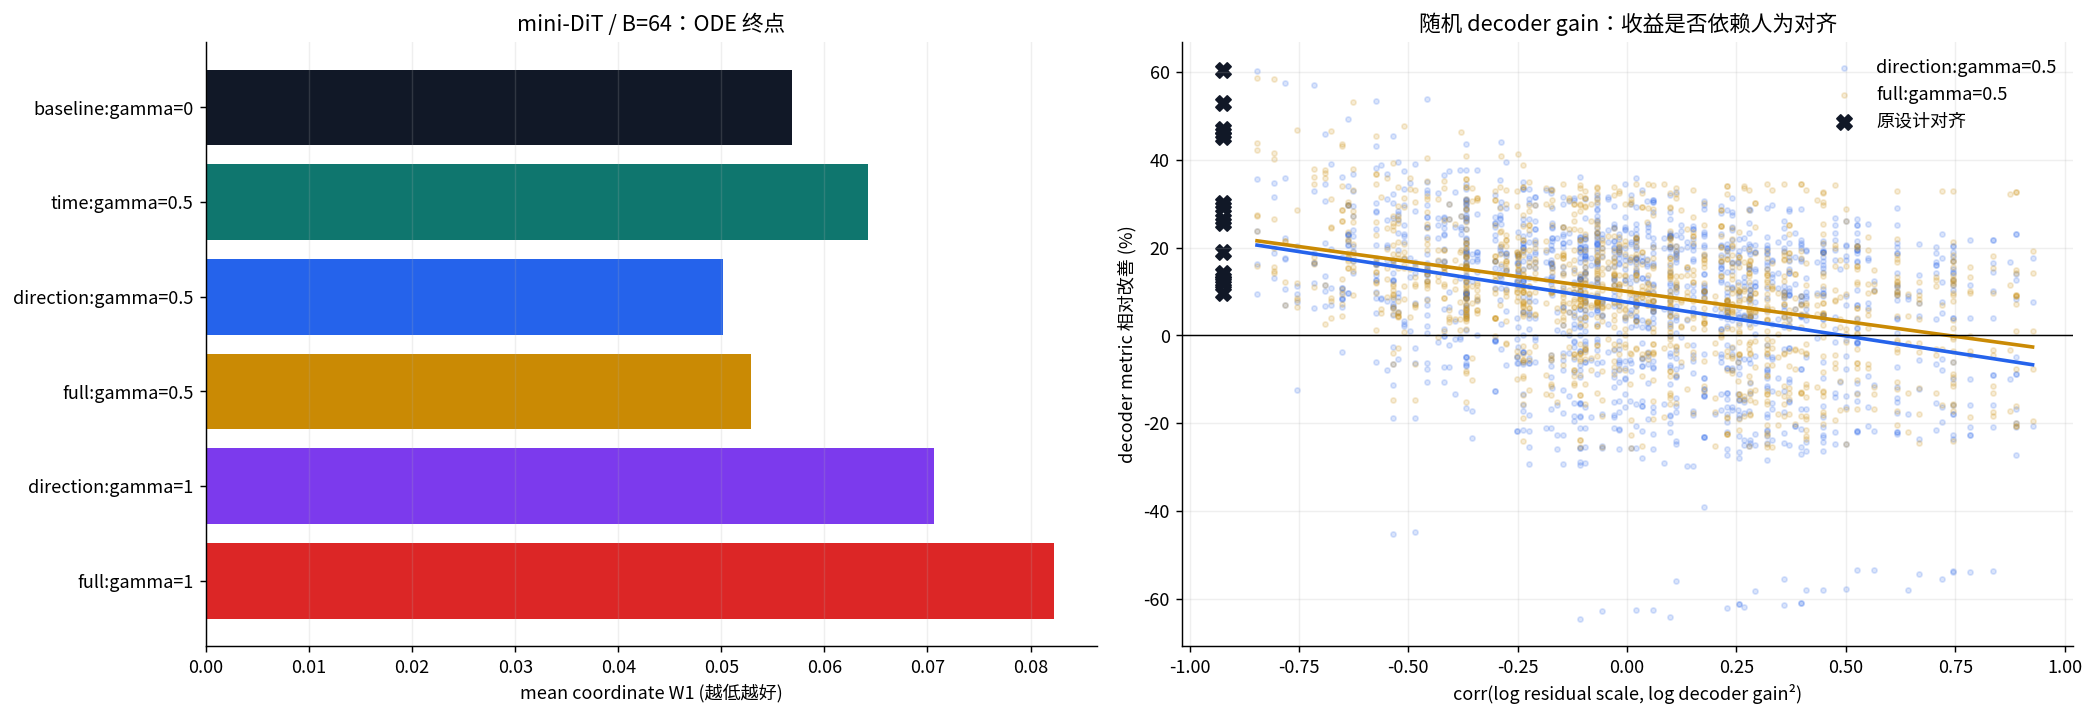

In [5]:
def plot_ode_and_permutation():
    figure, axes = plt.subplots(1, 2, figsize=(16, 5.4), constrained_layout=True)
    selected = generation_aggregate.set_index("treatment").reindex(ORDER).dropna()
    axes[0].barh(np.arange(len(selected)), selected["mean_w1"], color=[COLORS[name] for name in selected.index])
    axes[0].set_yticks(np.arange(len(selected)), selected.index)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("mean coordinate W1 (越低越好)")
    axes[0].set_title("mini-DiT / B=64：ODE 终点")
    axes[0].grid(axis="x", alpha=0.2)

    perm = toy_permutations.query("not is_original_alignment and treatment in ['direction:gamma=0.5', 'full:gamma=0.5']")
    sample = perm.sample(min(3000, len(perm)), random_state=0)
    for treatment, group in sample.groupby("treatment"):
        axes[1].scatter(group["residual_decoder_alignment"], 100 * group["relative_gain"], s=8, alpha=0.16, color=COLORS[treatment], label=treatment)
        coefficients = np.polyfit(group["residual_decoder_alignment"], group["relative_gain"], 1)
        grid = np.linspace(group["residual_decoder_alignment"].min(), group["residual_decoder_alignment"].max(), 100)
        axes[1].plot(grid, 100 * np.polyval(coefficients, grid), color=COLORS[treatment], linewidth=2)
    original = toy_permutations.query("is_original_alignment and treatment == 'full:gamma=0.5'")
    axes[1].scatter(original["residual_decoder_alignment"], 100 * original["relative_gain"], marker="X", s=70, color="#111827", label="原设计对齐")
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_xlabel("corr(log residual scale, log decoder gain²)")
    axes[1].set_ylabel("decoder metric 相对改善 (%)")
    axes[1].set_title("随机 decoder gain：收益是否依赖人为对齐")
    axes[1].legend(frameon=False)
    axes[1].grid(alpha=0.2)
    return figure

plot_ode_and_permutation();

### 5. Real RAE residual and predictability

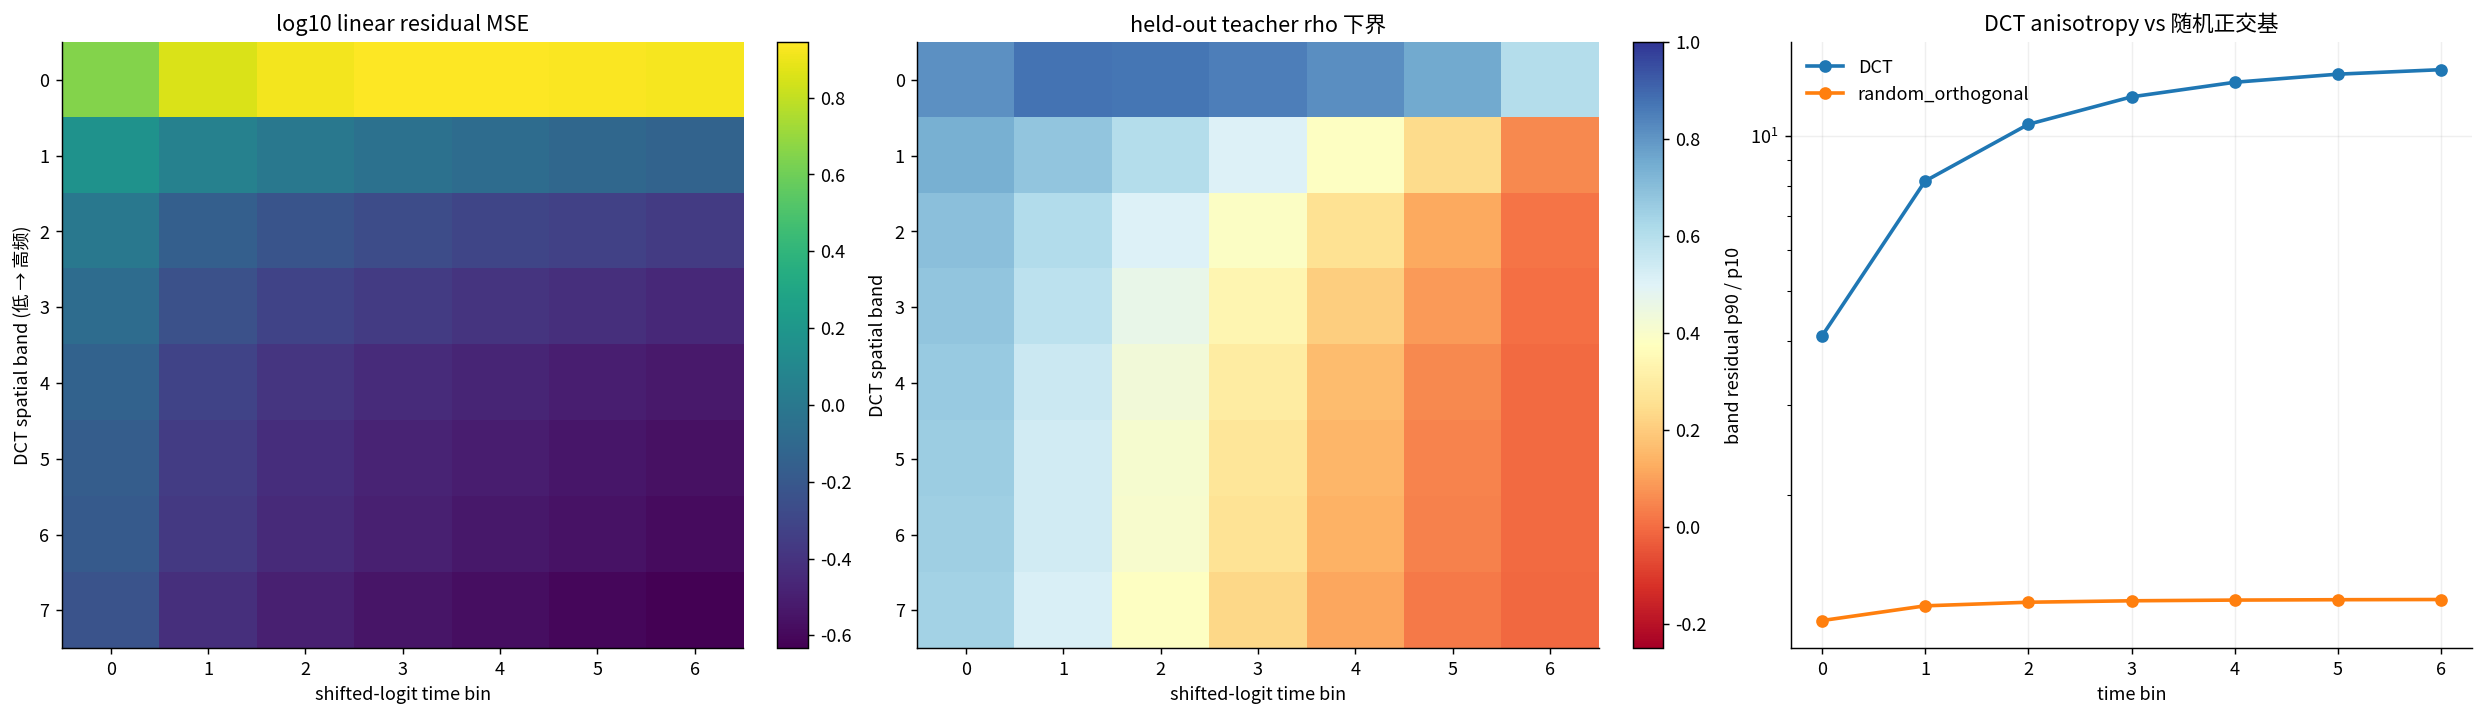

In [6]:
residual_spatial = rae_residual.groupby(["time_index", "t", "spatial_band"], as_index=False).agg(
    linear_residual=("linear_residual_mse", "mean"),
    teacher_mse=("teacher_mse", "mean"),
    rho_lower=("rho_lower_raw", "mean"),
)
residual_matrix = residual_spatial.pivot(index="spatial_band", columns="time_index", values="linear_residual")
rho_matrix = residual_spatial.pivot(index="spatial_band", columns="time_index", values="rho_lower")

def plot_rae_residual():
    figure, axes = plt.subplots(1, 3, figsize=(19, 5.4), constrained_layout=True)
    image0 = axes[0].imshow(np.log10(residual_matrix.clip(lower=1e-12)), aspect="auto", cmap="viridis")
    axes[0].set_title("log10 linear residual MSE")
    axes[0].set_xlabel("shifted-logit time bin")
    axes[0].set_ylabel("DCT spatial band (低 → 高频)")
    figure.colorbar(image0, ax=axes[0], fraction=0.046)
    image1 = axes[1].imshow(rho_matrix, aspect="auto", cmap="RdYlBu", vmin=-0.25, vmax=1.0)
    axes[1].set_title("held-out teacher rho 下界")
    axes[1].set_xlabel("shifted-logit time bin")
    axes[1].set_ylabel("DCT spatial band")
    figure.colorbar(image1, ax=axes[1], fraction=0.046)

    spread = basis_control.groupby(["basis", "time_index"], as_index=False)["linear_residual_variance"].agg(
        lambda values: np.quantile(values, 0.9) / max(np.quantile(values, 0.1), 1e-12)
    ).rename(columns={"linear_residual_variance": "p90_p10"})
    for basis, group in spread.groupby("basis"):
        axes[2].plot(group["time_index"], group["p90_p10"], marker="o", linewidth=2, label=basis)
    axes[2].set_yscale("log")
    axes[2].set_xlabel("time bin")
    axes[2].set_ylabel("band residual p90 / p10")
    axes[2].set_title("DCT anisotropy vs 随机正交基")
    axes[2].legend(frameon=False)
    axes[2].grid(alpha=0.2)
    return figure

plot_rae_residual();

### 6. Actual final-head gradient noise

,treatment,log_variance_slope,band_gsnr_mean
0,baseline:gamma=0,1.6413,0.0051
1,direction:gamma=0.5,0.6684,0.0050
2,direction:gamma=1,0.0193,0.0047
3,full:gamma=0.5,0.6265,0.0050
4,full:gamma=1,-0.3555,0.0048
5,time:gamma=0.5,1.6657,0.0050


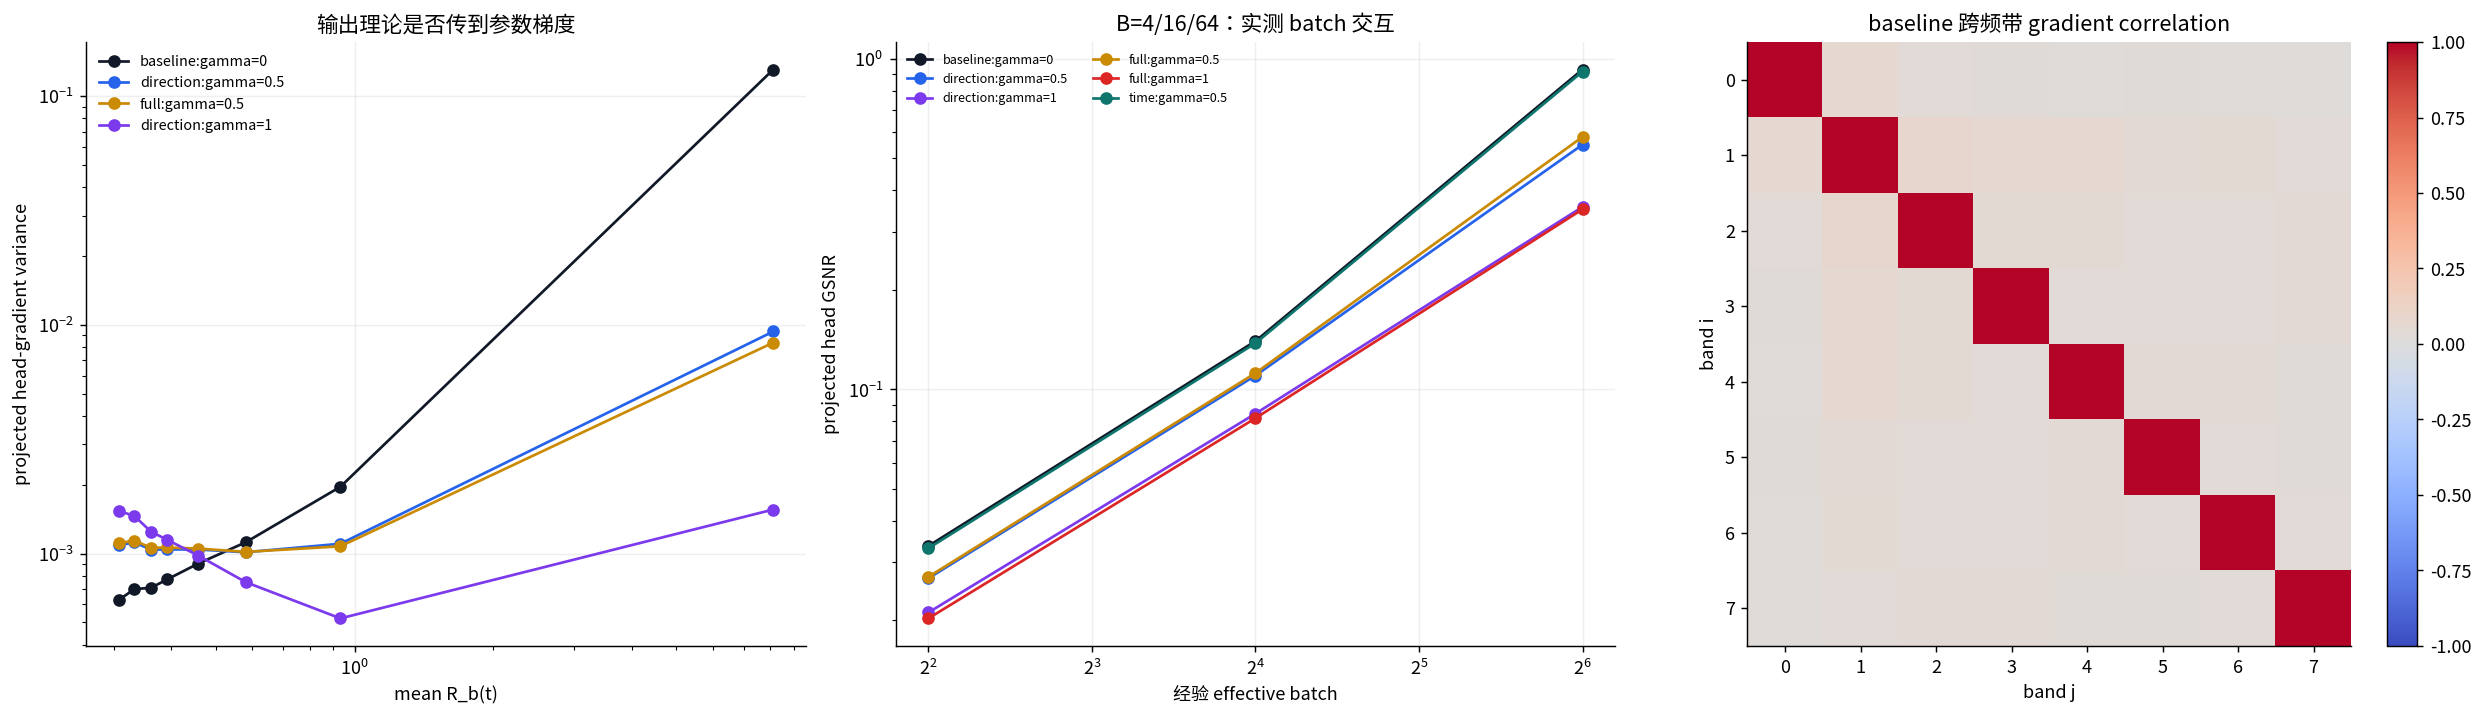

In [7]:
def gradient_slopes():
    rows = []
    for treatment, group in gradient_bands.groupby("treatment"):
        x = np.log(group["mean_linear_residual_variance"].clip(lower=1e-12))
        y = np.log(group["variance_trace"].clip(lower=1e-30))
        rows.append({"treatment": treatment, "log_variance_slope": np.polyfit(x, y, 1)[0], "band_gsnr_mean": group["gsnr"].mean()})
    return pd.DataFrame(rows)

slope_table = gradient_slopes()
display(slope_table.round(4))

def plot_gradient_audit():
    figure, axes = plt.subplots(1, 3, figsize=(19, 5.4), constrained_layout=True)
    for treatment in ["baseline:gamma=0", "direction:gamma=0.5", "full:gamma=0.5", "direction:gamma=1"]:
        group = gradient_bands.query("treatment == @treatment").sort_values("mean_linear_residual_variance")
        axes[0].plot(group["mean_linear_residual_variance"], group["variance_trace"], marker="o", color=COLORS[treatment], label=treatment)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("mean R_b(t)")
    axes[0].set_ylabel("projected head-gradient variance")
    axes[0].set_title("输出理论是否传到参数梯度")
    axes[0].legend(frameon=False, fontsize=8)
    axes[0].grid(alpha=0.2)

    empirical = gradient_summary.query("estimate == 'empirical' and treatment in @ORDER")
    for treatment, group in empirical.groupby("treatment"):
        axes[1].plot(group["effective_batch"], group["gsnr"], marker="o", color=COLORS[treatment], label=treatment)
    axes[1].set_xscale("log", base=2)
    axes[1].set_yscale("log")
    axes[1].set_xlabel("经验 effective batch")
    axes[1].set_ylabel("projected head GSNR")
    axes[1].set_title("B=4/16/64：实测 batch 交互")
    axes[1].legend(frameon=False, fontsize=7, ncol=2)
    axes[1].grid(alpha=0.2)

    treatment = "baseline:gamma=0"
    matrix = cross_band.query("treatment == @treatment").pivot(index="band_i", columns="band_j", values="correlation")
    image = axes[2].imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm")
    axes[2].set_xlabel("band j")
    axes[2].set_ylabel("band i")
    axes[2].set_title("baseline 跨频带 gradient correlation")
    figure.colorbar(image, ax=axes[2], fraction=0.046)
    return figure

plot_gradient_audit();

### 7. Frozen decoder observability

,spatial_band,pixel_sensitivity_mean,pixel_sensitivity_std,sample_count,epsilon,mean_linear_residual_variance,residual_rank,sensitivity_rank
0,0,0.16613,0.07606,16,0.02,8.11653,8.0,1.0
1,1,0.20587,0.10637,16,0.02,0.93173,7.0,2.0
2,2,0.24187,0.15511,16,0.02,0.58069,6.0,4.0
3,3,0.24135,0.17290,16,0.02,0.45785,5.0,3.0
4,4,0.27858,0.17865,16,0.02,0.39187,4.0,6.0
5,5,0.26815,0.18284,16,0.02,0.36124,3.0,5.0
6,6,0.29024,0.20735,16,0.02,0.33265,2.0,7.0
7,7,0.30551,0.25118,16,0.02,0.30817,1.0,8.0


Spearman(R_b, decoder sensitivity) = -0.952


epsilon,0.01,0.02,0.04
spatial_band,,,
0,0.1695,0.1661,0.1657
1,0.2110,0.2059,0.1945
2,0.2547,0.2419,0.2246
3,0.2452,0.2414,0.2262
4,0.2983,0.2786,0.2697
5,0.2900,0.2681,0.2483
6,0.3053,0.2902,0.2770
7,0.3123,0.3055,0.2876
band_rank_spearman,0.9524,0.9524,0.9762


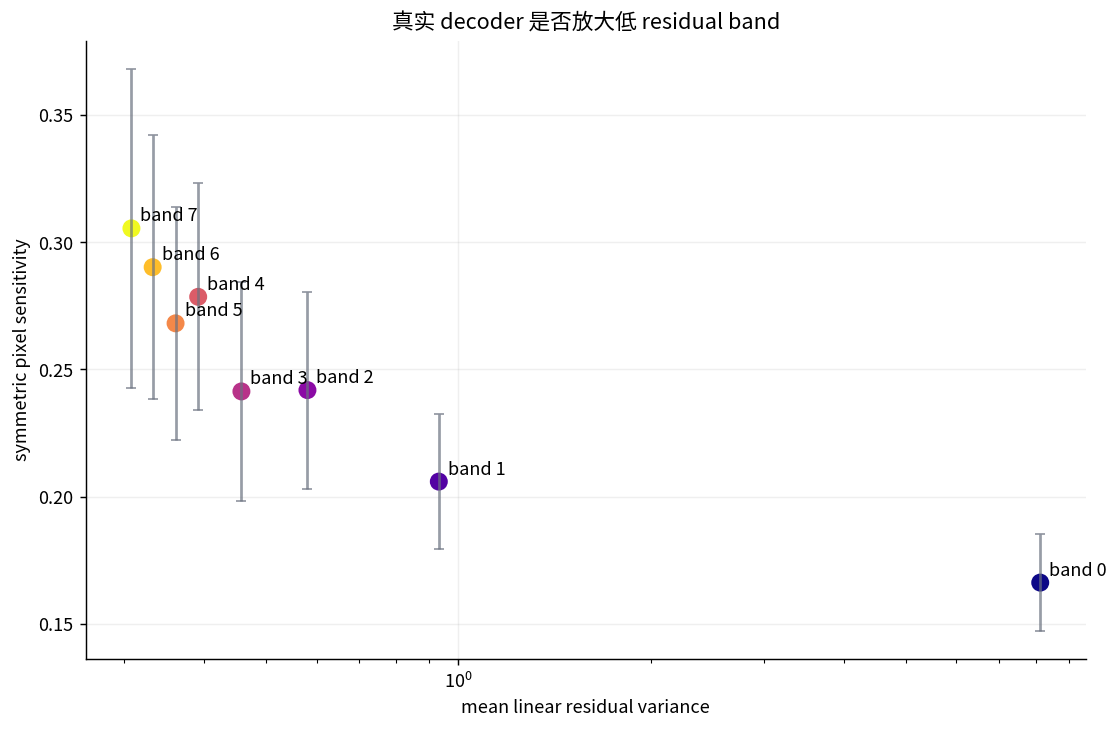

In [8]:
actual_residual = gradient_bands.query("treatment == 'baseline:gamma=0'")[["spatial_band", "mean_linear_residual_variance"]]
decoder_joined = decoder_sensitivity.merge(actual_residual, on="spatial_band")
decoder_joined["residual_rank"] = decoder_joined["mean_linear_residual_variance"].rank()
decoder_joined["sensitivity_rank"] = decoder_joined["pixel_sensitivity_mean"].rank()
decoder_spearman = decoder_joined[["residual_rank", "sensitivity_rank"]].corr().iloc[0, 1]
display(decoder_joined.round(5))
print(f"Spearman(R_b, decoder sensitivity) = {decoder_spearman:.3f}")
epsilon_stability = decoder_sweep.pivot(index="spatial_band", columns="epsilon", values="pixel_sensitivity_mean")
epsilon_stability.loc["band_rank_spearman"] = [
    decoder_sweep.query("epsilon == @epsilon")[["spatial_band", "pixel_sensitivity_mean"]].corr(method="spearman").iloc[0, 1]
    for epsilon in epsilon_stability.columns
]
display(epsilon_stability.round(4))

figure, axis = plt.subplots(figsize=(8.5, 5.5), constrained_layout=True)
axis.scatter(decoder_joined["mean_linear_residual_variance"], decoder_joined["pixel_sensitivity_mean"], s=80, c=decoder_joined["spatial_band"], cmap="plasma")
decoder_sem = decoder_joined["pixel_sensitivity_std"] / np.sqrt(decoder_joined["sample_count"])
axis.errorbar(decoder_joined["mean_linear_residual_variance"], decoder_joined["pixel_sensitivity_mean"], yerr=decoder_sem, fmt="none", ecolor="#6B7280", alpha=0.7, capsize=3)
for row in decoder_joined.itertuples():
    axis.annotate(f"band {row.spatial_band}", (row.mean_linear_residual_variance, row.pixel_sensitivity_mean), xytext=(5, 4), textcoords="offset points")
axis.set_xscale("log")
axis.set_xlabel("mean linear residual variance")
axis.set_ylabel("symmetric pixel sensitivity")
axis.set_title("真实 decoder 是否放大低 residual band")
axis.grid(alpha=0.2)
plt.show()

## Takeaways

### 8. Automatic gate and simple visualization API

In [9]:
def relative_toy_gain(treatment, metric="final_excess_mse"):
    pivot = toy_summary.pivot_table(index=["architecture", "batch_size", "seed"], columns="treatment", values=metric)
    return float(((pivot["baseline:gamma=0"] - pivot[treatment]) / pivot["baseline:gamma=0"]).mean())

residual_band_mean = residual_spatial.groupby("spatial_band")["linear_residual"].mean()
residual_spread = float(residual_band_mean.max() / residual_band_mean.min())
rho_band = residual_spatial.groupby("spatial_band")["rho_lower"].mean()
rho_range = float(rho_band.max() - rho_band.min())
slope_map = slope_table.set_index("treatment")["log_variance_slope"]
direction_gain = relative_toy_gain("direction:gamma=0.5")
time_gain = relative_toy_gain("time:gamma=0.5")
full_gain = relative_toy_gain("full:gamma=0.5")
ode_gain = float(generation_aggregate.set_index("treatment").loc["direction:gamma=0.5", "w1_gain"])
ode_wide = toy_generation.pivot(index="seed", columns="treatment", values="mean_coordinate_w1")
ode_wins = int((ode_wide["direction:gamma=0.5"] < ode_wide["baseline:gamma=0"]).sum())
mini_summary = toy_summary.query("architecture == 'mini_dit'")
mini_pivot = mini_summary.pivot(index=["batch_size", "seed"], columns="treatment", values="final_excess_mse")
mini_raw_gain = float(((mini_pivot["baseline:gamma=0"] - mini_pivot["direction:gamma=0.5"]) / mini_pivot["baseline:gamma=0"]).mean())
gradient_flattened = abs(slope_map["direction:gamma=0.5"]) < abs(slope_map["baseline:gamma=0"])
empirical_b64 = gradient_summary.query("estimate == 'empirical' and effective_batch == 64").set_index("treatment")
head_gsnr_ratio = float(empirical_b64.loc["direction:gamma=0.5", "gsnr"] / empirical_b64.loc["baseline:gamma=0", "gsnr"])
basis_spread = basis_control.groupby(["basis", "time_index"])["linear_residual_variance"].agg(
    lambda values: np.quantile(values, 0.9) / max(np.quantile(values, 0.1), 1e-12)
).groupby("basis").mean()
dct_structure_ratio = float(basis_spread["DCT"] / basis_spread["random_orthogonal"])

decision = pd.DataFrame([
    {"gate": "toy direction-only 有效", "observed": direction_gain, "criterion": "> 0", "pass": direction_gain > 0},
    {"gate": "不是纯 time-only 效应", "observed": direction_gain - time_gain, "criterion": "> 0", "pass": direction_gain > time_gain},
    {"gate": "ODE 终点同步改善", "observed": ode_gain, "criterion": "> 0 且 >=4/5 wins", "pass": ode_gain > 0 and ode_wins >= 4},
    {"gate": "mini-DiT raw MSE 稳定改善（警告）", "observed": mini_raw_gain, "criterion": "> 0", "pass": mini_raw_gain > 0},
    {"gate": "RAE residual 跨 band", "observed": residual_spread, "criterion": ">= 10x", "pass": residual_spread >= 10},
    {"gate": "DCT anisotropy 非任意基现象", "observed": dct_structure_ratio, "criterion": ">= 3x random", "pass": dct_structure_ratio >= 3},
    {"gate": "RAE predictability 有分层", "observed": rho_range, "criterion": ">= 0.15", "pass": rho_range >= 0.15},
    {"gate": "gamma=.5 flatten 参数梯度斜率", "observed": float(slope_map["direction:gamma=0.5"]), "criterion": "|slope| < baseline", "pass": bool(gradient_flattened)},
    {"gate": "整体 head GSNR 保留（警告）", "observed": head_gsnr_ratio, "criterion": ">= 0.8x baseline", "pass": head_gsnr_ratio >= 0.8},
    {"gate": "低 R / 高 decoder sensitivity 错位", "observed": float(decoder_spearman), "criterion": "Spearman < 0", "pass": decoder_spearman < 0},
])
display(decision)
passed = int(decision["pass"].sum())
hard_gates = [
    "不是纯 time-only 效应", "ODE 终点同步改善", "RAE residual 跨 band",
    "DCT anisotropy 非任意基现象", "RAE predictability 有分层",
    "gamma=.5 flatten 参数梯度斜率", "低 R / 高 decoder sensitivity 错位",
]
hard_pass = bool(decision.set_index("gate").loc[hard_gates, "pass"].all())
warning_mask = decision["gate"].str.contains("警告")
warning_count = int((~decision.loc[warning_mask, "pass"]).sum())
if hard_pass:
    recommendation = (
        "通过 tiny RAE microtraining 门槛，但未通过大训练门槛：只比较 baseline 与 normalized "
        "direction gamma=.5；不加 decoder loss，并把 raw MSE/整体 GSNR 作为停止指标。"
    )
elif bool(decision.iloc[:3]["pass"].all()) and passed >= 6:
    recommendation = "继续低成本机制验证；信号存在，但真实 RAE 的必要条件尚未全部闭合。"
else:
    recommendation = "暂停真实 RAE 训练：当前收益不足以支持频带预条件主线。"
print(f"通过 {passed}/{len(decision)} 个门槛。")
print(f"ODE paired wins: {ode_wins}/5；未校正单侧 sign-test p={(sum(__import__('math').comb(5, k) for k in range(ode_wins, 6)) / 32):.4f}")
print(f"反证警告未通过数量：{warning_count}")
print(recommendation)

def V(view="all"):
    # 最简入口：V('toy')、V('rae')、V('decision') 或 V('all')。
    view = view.lower()
    if view in {"toy", "all"}:
        plot_toy_gate();
        plot_ode_and_permutation();
    if view in {"rae", "all"}:
        plot_rae_residual();
        plot_gradient_audit();
    if view in {"decision", "all"}:
        display(decision)
        print(recommendation)
    plt.show()

print("可视化入口：V('toy') / V('rae') / V('decision') / V('all')")

,gate,observed,criterion,pass
0,toy direction-only 有效,0.032364,> 0,True
1,不是纯 time-only 效应,0.184272,> 0,True
2,ODE 终点同步改善,0.117369,> 0 且 >=4/5 wins,True
3,mini-DiT raw MSE 稳定改善（警告）,-0.027638,> 0,False
4,RAE residual 跨 band,23.454567,>= 10x,True
5,DCT anisotropy 非任意基现象,8.612540,>= 3x random,True
6,RAE predictability 有分层,0.527508,>= 0.15,True
7,gamma=.5 flatten 参数梯度斜率,0.668361,|slope| < baseline,True
8,整体 head GSNR 保留（警告）,0.592639,>= 0.8x baseline,False
9,低 R / 高 decoder sensitivity 错位,-0.952381,Spearman < 0,True


通过 8/10 个门槛。
ODE paired wins: 4/5；未校正单侧 sign-test p=0.1875
反证警告未通过数量：2
通过 tiny RAE microtraining 门槛，但未通过大训练门槛：只比较 baseline 与 normalized direction gamma=.5；不加 decoder loss，并把 raw MSE/整体 GSNR 作为停止指标。
可视化入口：V('toy') / V('rae') / V('decision') / V('all')


### Interpretation boundary

- 即使门槛通过，也只支持一次 **tiny microtraining**，不支持直接做 ImageNet-1K 800 epoch 大训练。
- 如果 `direction-only` 胜、`time-only` 不胜，才说明关键来自同一 timestep 内的方向竞争。
- 如果 RAE 输出 residual 被均衡，但 final-head 梯度斜率没有变平，说明 Jacobian/attention 混合抵消了输出空间理论。
- 如果低 residual band 并不对应高 decoder sensitivity，toy 的 decoder 收益就不具备真实迁移依据。
- 下一次训练最多比较 baseline、`direction gamma=0.5` 和 LR-tuned `direction gamma=1`；不同时加入 decoder-aware、$N^{-1/2}$ 或新网络结构。